# Why and when should we use correlation coefficients designed for ordinal-scale data?

Standard correlation coefficients such as Pearson's are not appropriate for ordinal data, because they assume interval-scale measurements and linear relationships between variables. For ordinal data—such as Likert-scale responses or exam grades—these assumptions do not hold, and applying Pearson's coefficient can produce biased (typically underestimated) correlation estimates.

This page first demonstrates the problem through simulation, then introduces polyserial and polychoric correlation coefficients as the appropriate alternative for ordinal data.

## The Problem: Pearson's Correlation Underestimates the True Relationship

To see the issue concretely, consider a continuous variable $X$ and a variable $Y$ that is dichotomized (split into two categories) from an underlying continuous variable. We simulate data with a true correlation of $\rho=0.5$ between $X$ and the latent variable behind $Y$, then repeatedly estimate Pearson's correlation coefficient between $X$ and the observed, dichotomized $Y$.

The histogram below shows the distribution of these estimates across 1,000 simulated datasets.

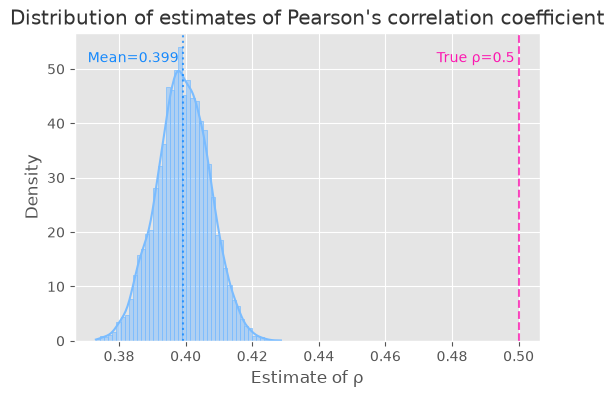

In [1]:
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')


def generate_data(rho=0.5, size=100000, seed=0):
    np.random.seed(seed)
    data = np.random.multivariate_normal(mean=[0, 0], cov=[[1, rho], [rho, 1]], size=size)
    x, y = data[:, 0], data[:, 1]
    yd = 1 * (y >= np.mean(y))  # dichotomize y by mean
    return x, yd


def simulate_estimates(n=10000, n_trials=1000, true_rho=0.5):
    estimates = []
    for seed in range(n_trials):
        x, yd = generate_data(rho=true_rho, size=n, seed=seed)
        estimate = pearsonr(x, yd)[0]
        estimates.append(estimate)
    return np.array(estimates)


def plot(estimates, true_rho):
    fig, ax = plt.subplots(figsize=[6, 4])
    ax.set_title("Distribution of estimates of Pearson's correlation coefficient", color="#333333")
    ax.set_xlabel("Estimate of ρ")

    hist = sns.histplot(estimates, ax=ax, color="#7abcff", edgecolor="#7abcff", kde=True, stat="density")

    max_height = max([p.get_height() for p in hist.patches])
    ax.axvline(true_rho, color="#FF00AA", linestyle="--", alpha=0.7)
    ax.text(true_rho, max_height * 0.95, f"True ρ={true_rho:.1f} ", color="#FF00AA", alpha=0.9, ha="right")

    r = estimates.mean()
    ax.axvline(r, color="#007fff", linestyle=":", alpha=0.7)
    ax.text(r, max_height * 0.95, f"Mean={r:.3f} ", color="#007fff", alpha=0.9, ha="right")


estimates = simulate_estimates(n=10000, n_trials=5000, true_rho=0.5)
plot(estimates, true_rho=0.5)


As the plot shows, the mean of the estimates is noticeably below the true value of $\rho=0.5$. Dichotomizing a continuous variable induces this downward (attenuation) bias in Pearson's correlation coefficient—and the same kind of bias arises whenever the observed data are ordinal categories derived from an underlying continuous trait, such as survey responses.

## The Solution: Polyserial and Polychoric Correlation

**Polyserial** and **polychoric** correlation coefficients (Drasgow, 1986) are designed to handle this situation. They assume that the **observed ordinal or categorical variables arise from underlying latent continuous variables** that have been discretized by thresholds:

- **Polyserial correlation** estimates the relationship between one continuous variable and one ordinal variable.
- **Polychoric correlation** estimates the relationship between two ordinal variables.

For example, if you are working with survey or questionnaire data, where participants respond using ordered categories (e.g., "strongly disagree" to "strongly agree"), polyserial or polychoric correlations can capture the latent relationship between the attitudes or traits that those responses reflect.

Using correlation coefficients tailored for ordinal-scale data helps preserve the meaningful order of categories and avoids the misleading results that come from inappropriately applying Pearson or Spearman correlation.

## Numerical Example

Here is a numerical example to illustrate the concept, using the polychoric correlation.

Suppose there are latent variables $X^*$ and $Y^*$ that follow a bivariate standard normal distribution:

$$
\left(X^*, Y^*\right) \sim \mathcal{N}\left(
\begin{bmatrix}
0 \\
0
\end{bmatrix},
\begin{bmatrix}
1 & \rho \\
\rho & 1
\end{bmatrix}
\right)
$$

The observable ordinal variables $X$ and $Y$ are obtained by discretizing the latent variables using certain thresholds.

We then discretize $X^*$ and $Y^*$ into ordinal categories with varying numbers of bins, and compare the following coefficients calculated from the observed, discretized data against the true value of $\rho$. To assess the variability of each estimate, we repeat this process across many simulated datasets:

1. Polychoric correlation coefficient
2. Pearson correlation coefficient
3. Spearman correlation coefficient
4. Kendall correlation coefficient

The figure below shows the mean estimated coefficients (with 95% confidence intervals across simulation trials) for different numbers of categories.

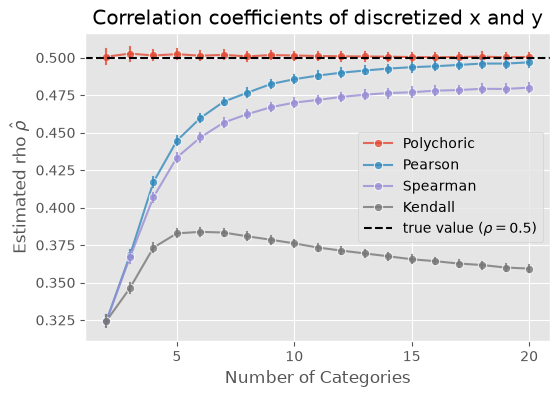

In [2]:
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

from ordinalcorr import polychoric
from scipy.stats import pearsonr, spearmanr, kendalltau


# settings
n_samples = 500
n_trials = 500
rho = 0.5
random_state = 42
n_jobs = -1  # use all CPU cores

cov = np.array(
    [
        [1.0, rho],
        [rho, 1.0],
    ]
)


def run_trial(trial, seed):
    rng = np.random.default_rng(seed)

    # generate bivariate normal data
    data = rng.multivariate_normal(
        mean=[0, 0],
        cov=cov,
        size=n_samples,
    )

    continuous_data = pd.DataFrame(data, columns=["x", "y"])

    trial_results = []

    for n_categories in range(2, 21):
        # discretize the data
        x = pd.cut(
            continuous_data["x"],
            bins=n_categories,
            labels=False,
        ).to_numpy()

        y = pd.cut(
            continuous_data["y"],
            bins=n_categories,
            labels=False,
        ).to_numpy()

        trial_results += [
            dict(
                trial=trial,
                method="Polychoric",
                value=polychoric(x, y),
                n_categories=n_categories,
            ),
            dict(
                trial=trial,
                method="Pearson",
                value=pearsonr(x, y).statistic,
                n_categories=n_categories,
            ),
            dict(
                trial=trial,
                method="Spearman",
                value=spearmanr(x, y).statistic,
                n_categories=n_categories,
            ),
            dict(
                trial=trial,
                method="Kendall",
                value=kendalltau(x, y).statistic,
                n_categories=n_categories,
            ),
        ]

    return trial_results


# make independent seeds for each trial
seed_sequence = np.random.SeedSequence(random_state)
child_seeds = seed_sequence.spawn(n_trials)

# run trials in parallel
results_nested = Parallel(n_jobs=n_jobs)(
    delayed(run_trial)(trial, child_seeds[trial])
    for trial in range(n_trials)
)

# flatten
results = pd.DataFrame(
    row
    for trial_results in results_nested
    for row in trial_results
)

# plot
fig, ax = plt.subplots(figsize=[6, 4], dpi=100)

sns.lineplot(
    x="n_categories",
    y="value",
    data=results,
    hue="method",
    marker="o",
    errorbar=("ci", 95),
    err_style="bars",
    ax=ax,
    alpha=0.8,
)

ax.axhline(
    rho,
    label=rf"true value ($\rho={rho}$)",
    color="black",
    linestyle="--",
)

ax.set(
    xlabel="Number of Categories",
    ylabel=r"Estimated rho $\hat{\rho}$",
    title="Correlation coefficients of discretized x and y",
)

ax.set_xticks(range(5, 21, 5))

_ = ax.legend()

## Conclusion

The polychoric correlation is designed for this situation and, on average, recovers the true correlation well across all numbers of categories.

In contrast, Pearson correlation tends to underestimate the true correlation, especially when the number of categories is small (i.e., when the data is coarsely discretized). Spearman and Kendall correlations are also affected by discretization and are not well-suited for recovering the underlying linear relationship in this type of data.

For ordinal-scale data—such as Likert-scale survey items or discretized ratings—polyserial and polychoric correlations are therefore the more appropriate choice.

## References

- Bedrick, E. J. (1995). A note on the attenuation of correlation. *British Journal of Mathematical and Statistical Psychology, 48*(2), 271–280.
- Drasgow, F. (1986). Polychoric and polyserial correlations. In S. Kotz & N. Johnson (Eds.), *The Encyclopedia of Statistics* (Vol. 7, pp. 68–74). Wiley.